# IPTU / Cadastro Predial (São Paulo)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CSV_PATH = os.path.join("..", "data", "raw", "iptu_2025.csv")

In [2]:
# carregamento em csv
df_iptu = pd.read_csv(CSV_PATH, low_memory=False)
df_iptu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3806436 entries, 0 to 3806435
Data columns (total 27 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   ano                           int64  
 1   data_cadastramento            object 
 2   numero_notificacao            int64  
 3   numero_contribuinte           int64  
 4   ano_inicio_vida_contribuinte  int64  
 5   mes_inicio_vida_contribuinte  int64  
 6   logradouro                    object 
 7   numero_imovel                 float64
 8   numero_condominio             object 
 9   complemento                   object 
 10  bairro                        object 
 11  cep                           int64  
 12  ano_construcao_corrigida      int64  
 13  fator_obsolescencia           float64
 14  referencia_imovel             object 
 15  finalidade_imovel             object 
 16  tipo_construcao               object 
 17  tipo_terreno                  object 
 18  fracao_ideal          

In [3]:
df_iptu.isna().sum()

ano                                 0
data_cadastramento                  0
numero_notificacao                  0
numero_contribuinte                 0
ano_inicio_vida_contribuinte        0
mes_inicio_vida_contribuinte        0
logradouro                          0
numero_imovel                   84318
numero_condominio                   0
complemento                         0
bairro                              0
cep                                 0
ano_construcao_corrigida            0
fator_obsolescencia                 0
referencia_imovel                   0
finalidade_imovel                   0
tipo_construcao                     0
tipo_terreno                        0
fracao_ideal                        0
area_terreno                        0
area_construida                     0
area_ocupada                        0
quantidade_pavimento                0
quantidade_esquina_imovel           0
testada_imovel                      0
valor_terreno                       0
valor_constr

In [4]:
# estatísticas descritivas
df_iptu.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ano,3806436.0,NaN,NaN,NaN,2025.0,0.0,2025.0,2025.0,2025.0,2025.0,2025.0
data_cadastramento,3806436,1,2025-01-01,3806436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
numero_notificacao,3806436.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
numero_contribuinte,3806436.0,NaN,NaN,NaN,10071628220.735588,7317318521.271715,100300014.0,4305700323.75,8604700238.0,14810100114.75,31012000017.0
ano_inicio_vida_contribuinte,3806436.0,NaN,NaN,NaN,1990.151127,19.980444,1963.0,1972.0,1988.0,2009.0,2025.0
mes_inicio_vida_contribuinte,3806436.0,NaN,NaN,NaN,2.012784,2.626037,1.0,1.0,1.0,1.0,12.0
logradouro,3806436,40856,AV PAULISTA,13255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
numero_imovel,3722118.0,NaN,NaN,NaN,590.969253,1146.786178,0.0,104.0,265.0,623.0,99541.0
numero_condominio,3806436,43,00-0,1634424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
complemento,3806436,669157,,970462,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# criação de novas colunas
df_iptu["valor_venal_total"] = df_iptu[["valor_terreno", "valor_construcao"]].sum(axis=1)
df_iptu["valor_m2_construcao"] = df_iptu["valor_construcao"] / df_iptu["area_construida"].replace(0, np.nan)
df_iptu["idade_imovel"] = (df_iptu["ano"] - df_iptu["ano_construcao_corrigida"]).where(lambda s: s.between(0, 150))
df_iptu["regiao_cep"] = df_iptu["cep"].astype("string").str.zfill(8).str[:2]

# estatísticas descritivas das novas colunas
df_iptu[["valor_venal_total", "valor_m2_construcao", "idade_imovel"]].describe()

,valor_venal_total,valor_m2_construcao,idade_imovel
count,3.806436e+06,3.705957e+06,3.705954e+06
mean,5.645903e+03,3.391562e+01,3.364094e+01
std,4.488740e+03,5.849015e+01,1.826957e+01
min,9.300000e+01,2.804295e-03,1.000000e+00
25%,2.755000e+03,1.414286e+01,1.800000e+01
50%,3.922000e+03,2.220000e+01,3.400000e+01
75%,6.933000e+03,3.566000e+01,4.800000e+01
max,3.874300e+04,3.991000e+03,1.390000e+02


In [6]:
df_iptu['finalidade_imovel'].unique()

array(['Armazéns Gerais E Depósitos', 'Residência',
       'Estação Radioemissora, De Televisão Ou Empresa Jornalística',
       'Apartamento Em Condomínio',
       'Garagem (Unidade Autônoma) Em Edifício Em Condomínio De Escritórios, Consultórios Ou Misto',
       'Garagem (Unidade Autônoma) Em Edifício Em Condomínio De Uso Exclusivamente Residencial',
       'Loja',
       'Outras Edificações De Uso Coletivo, Com Utilização Múltipla',
       'Prédio De Escritório Ou Consultório, Não Em Condomínio, Com Ou Sem Lojas',
       'Indústria',
       'Escritório/Consultório Em Condomínio (Unidade Autônoma)',
       'Templo', 'Loja Em Edifício Em Condomínio (Unidade Autônoma)',
       'Outras Edificações De Uso Comercial, Com Utilização Múltipla',
       'Escola',
       'Outras Edificações De Uso De Serviço, Com Utilização Múltipla',
       'Outras Edificações De Uso Especial, Com Utilização Múltipla',
       'Garagem (Unidade Autônoma) De Prédio De Garagens',
       'Não Residencial', 'Club

In [7]:
tipos_habitacionais = [
    'Residência',
    'Apartamento Em Condomínio',
    'Residência E Outro Uso (Predominância Residencial)',
    'Hotel, Pensão Ou Hospedaria',
    'Residência Coletiva, Exclusive Cortiço (Mais De Uma Residência No Lote)',
    'Prédio De Apartamento, Não Em Condomínio, De Uso Misto (Apartamentos E Escritórios E/Ou Consultórios), Com Ou Sem Loja (Predominância Residencial)',
    'Prédio De Apartamento, Não Em Condomínio, De Uso Exclusivamente Residencial',
    'Flat Residencial Em Condomínio'
]

df_iptu = df_iptu[df_iptu['finalidade_imovel'].isin(tipos_habitacionais)].copy()

print(df_iptu['finalidade_imovel'].value_counts())

finalidade_imovel
Apartamento Em Condomínio                                                                                                                             1629717
Residência                                                                                                                                            1097232
Residência Coletiva, Exclusive Cortiço (Mais De Uma Residência No Lote)                                                                                206812
Residência E Outro Uso (Predominância Residencial)                                                                                                      85892
Hotel, Pensão Ou Hospedaria                                                                                                                              5974
Flat Residencial Em Condomínio                                                                                                                           5828
Prédio De Apartamento, Não Em Cond

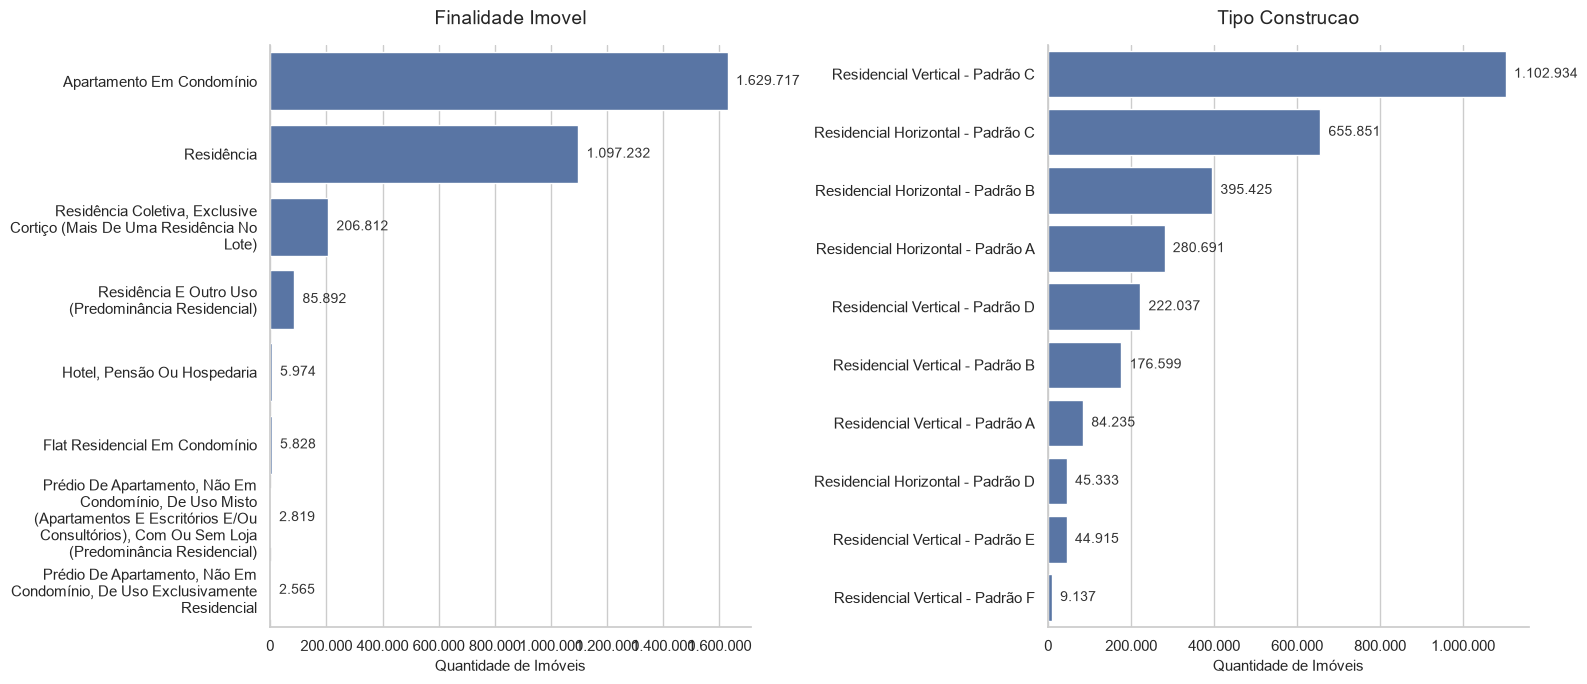

In [8]:
# análise de variáveis categóricas
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, col in zip(axes, ["finalidade_imovel", "tipo_construcao"]):
    counts = df_iptu[col].value_counts().head(10)
    labels_formatadas = [textwrap.fill(str(label), width=35) for label in counts.index]
    
    sns.barplot(x=counts.values, y=labels_formatadas, ax=ax, color="#4C72B0", edgecolor="white")
    
    ax.set_title(col.replace('_', ' ').title(), fontsize=14, pad=15)
    ax.set_xlabel("Quantidade de Imóveis", fontsize=11)
    ax.set_ylabel("")
    
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.')))
    ax.bar_label(ax.containers[0], fmt=lambda x: f' {x:,.0f}'.replace(',', '.'), padding=3, fontsize=10, color="#333333")
    
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [9]:
# análise de variáveis numéricas
bairro_stats = (
    df_iptu.groupby("bairro")["valor_venal_total"]
    .describe()
    .query("count >= 100")
    .sort_values("50%", ascending=False)
)
bairro_stats

,count,mean,std,min,25%,50%,75%,max
bairro,,,,,,,,
E VG,245.0,16935.730612,3118.355965,2594.0,15021.0,18722.0,18722.0,19998.0
ED MASSIS FIVE STARS,134.0,18644.000000,0.000000,18644.0,18644.0,18644.0,18644.0,18644.0
JARDINS,445.0,17790.370787,2403.023857,5151.0,17879.0,18467.0,18932.0,20899.0
JARDIM PAULISTA,6256.0,16926.331841,3025.459238,3770.0,15772.0,18454.0,18820.0,20899.0
CERQUEIRA CEZAR,414.0,16950.265700,3061.207561,3399.0,13629.0,18355.5,18619.0,20899.0
...,...,...,...,...,...,...,...,...
JARDIM FONTALIS,192.0,1648.005208,89.544367,1605.0,1605.0,1605.0,1605.0,2320.0
PRQ FLORESTAL,122.0,1617.221311,51.286025,1605.0,1605.0,1605.0,1605.0,1863.0
COCAIA,307.0,1727.700326,192.683767,1605.0,1605.0,1605.0,1863.0,2319.0


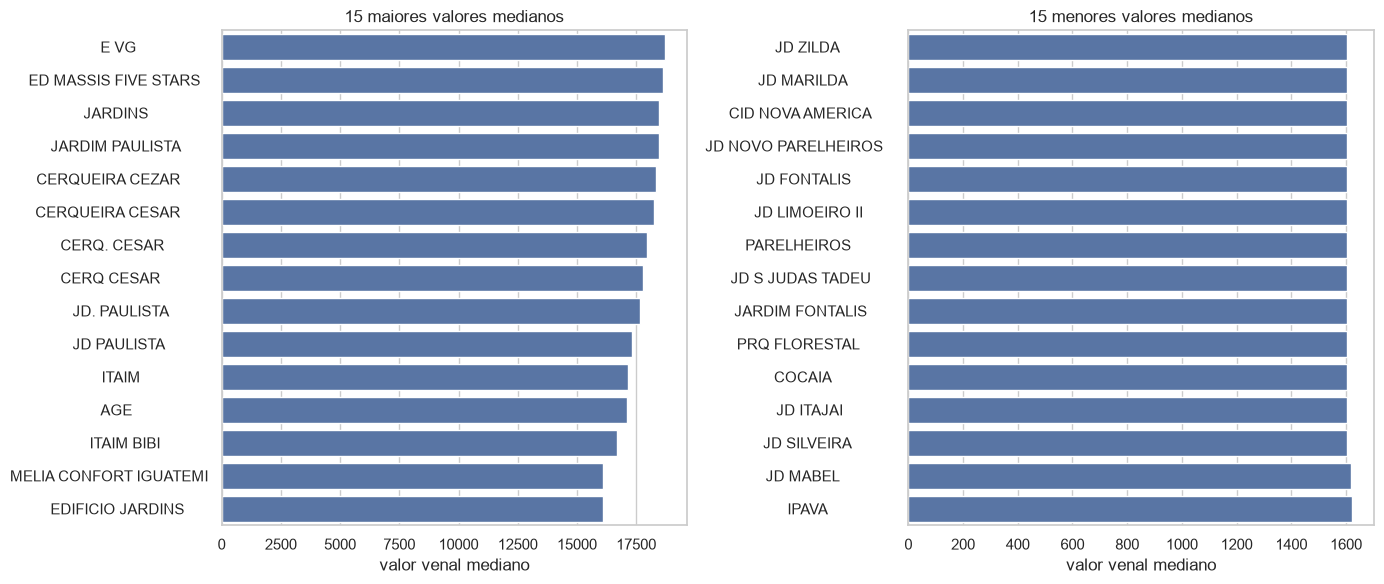

In [10]:
# visualização dos bairros com maiores e menores valores medianos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, subset, rotulo in (
    (axes[0], bairro_stats["50%"].nlargest(15), "maiores"),
    (axes[1], bairro_stats["50%"].nsmallest(15), "menores"),
):
    sns.barplot(x=subset.values, y=subset.index, ax=ax, color="#4C72B0")
    ax.set(title=f"15 {rotulo} valores medianos", xlabel="valor venal mediano", ylabel="")

plt.tight_layout()
plt.show()

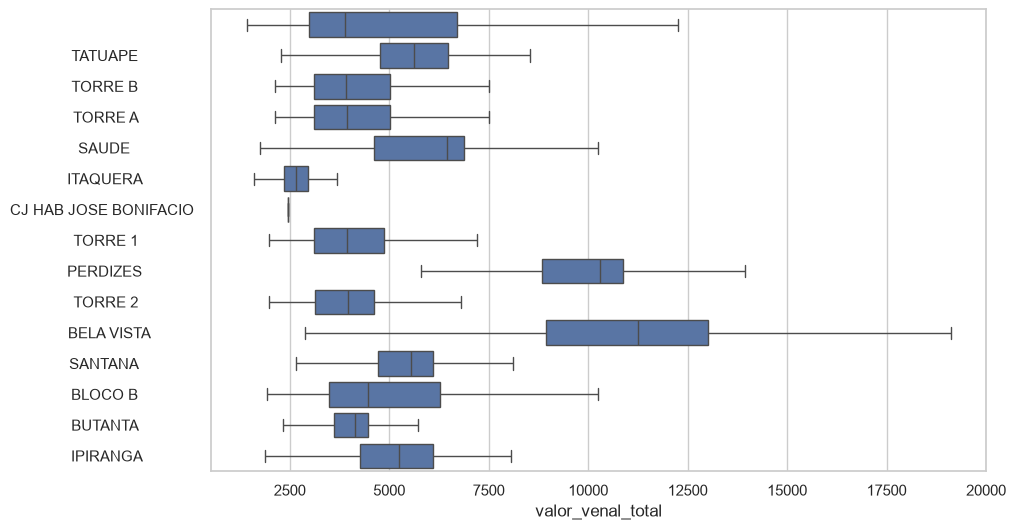

In [11]:
# visualização dos bairros com maiores valores medianos sem outliers
top_bairros = bairro_stats["count"].nlargest(15).index

ax = sns.boxplot(
    data=df_iptu[df_iptu["bairro"].isin(top_bairros)],
    x="valor_venal_total",
    y="bairro",
    order=top_bairros,
    showfliers=False,
    color="#4C72B0",
)
ax.set(ylabel="")
plt.show()

In [12]:
# análise de variáveis numéricas por região do CEP
df_iptu.groupby("regiao_cep")["valor_venal_total"].describe().sort_values("50%", ascending=False)

,count,mean,std,min,25%,50%,75%,max
regiao_cep,,,,,,,,
01,301623.0,11100.522918,4451.804958,2596.0,7492.0,10483.0,13745.0,36940.0
04,737213.0,6135.156663,3877.645936,1152.0,3238.0,4931.0,7847.0,20418.0
05,587818.0,4912.571658,3120.785920,1355.0,2705.0,3823.0,5976.0,15174.0
03,615051.0,3735.278500,1201.107504,1455.0,2843.0,3461.0,4349.0,13545.0
02,437294.0,3495.816755,1010.758615,1505.0,2913.0,3383.0,3938.0,8309.0
08,357582.0,2242.858950,369.821249,1271.0,1979.0,2205.0,2457.0,3802.0
00,258.0,2188.271318,225.434341,1681.0,2197.0,2197.0,2197.0,3283.0


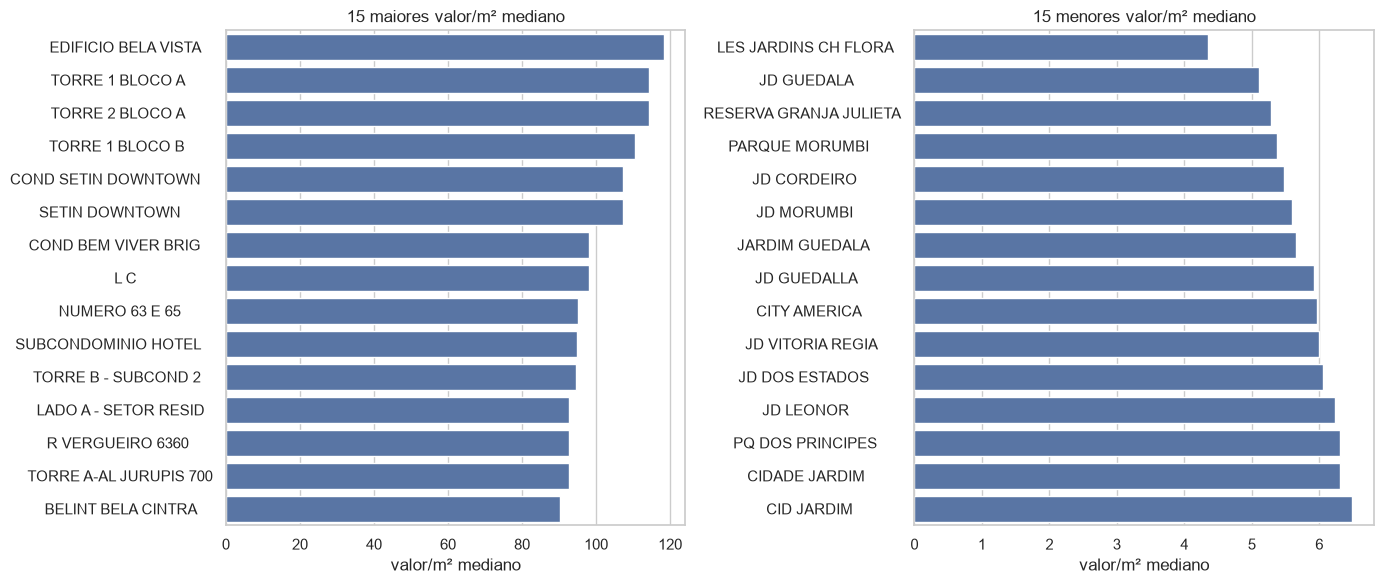

In [21]:
# análise de variáveis numéricas por bairro
m2_stats = df_iptu.groupby("bairro")["valor_m2_construcao"].describe().query("count >= 100")["50%"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, subset, rotulo in (
    (axes[0], m2_stats.nlargest(15), "maiores"),
    (axes[1], m2_stats.nsmallest(15), "menores"),
):
    sns.barplot(x=subset.values, y=subset.index, ax=ax, color="#4C72B0")
    ax.set(title=f"15 {rotulo} valor/m² mediano", xlabel="valor/m² mediano", ylabel="")

plt.tight_layout()
plt.show()

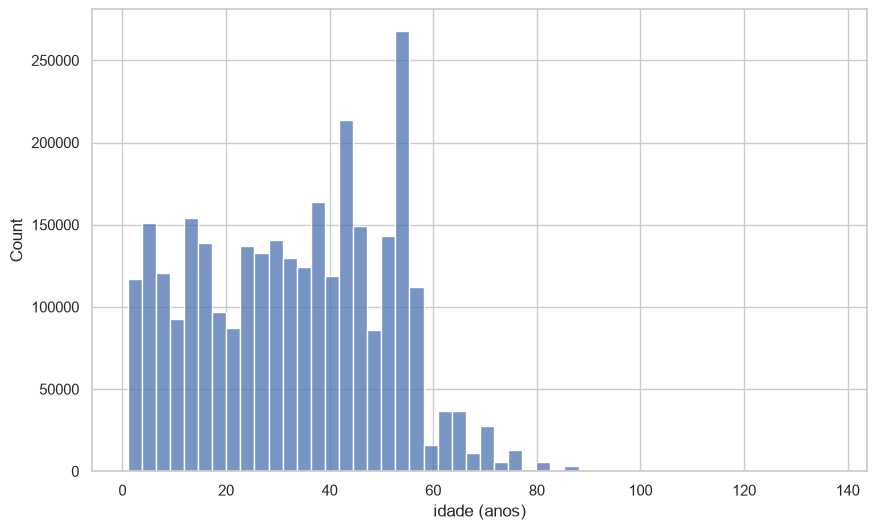

In [14]:
# análise da idade dos imóveis
ax = sns.histplot(df_iptu, x="idade_imovel", bins=50, color="#4C72B0")
ax.set(xlabel="idade (anos)")
plt.show()

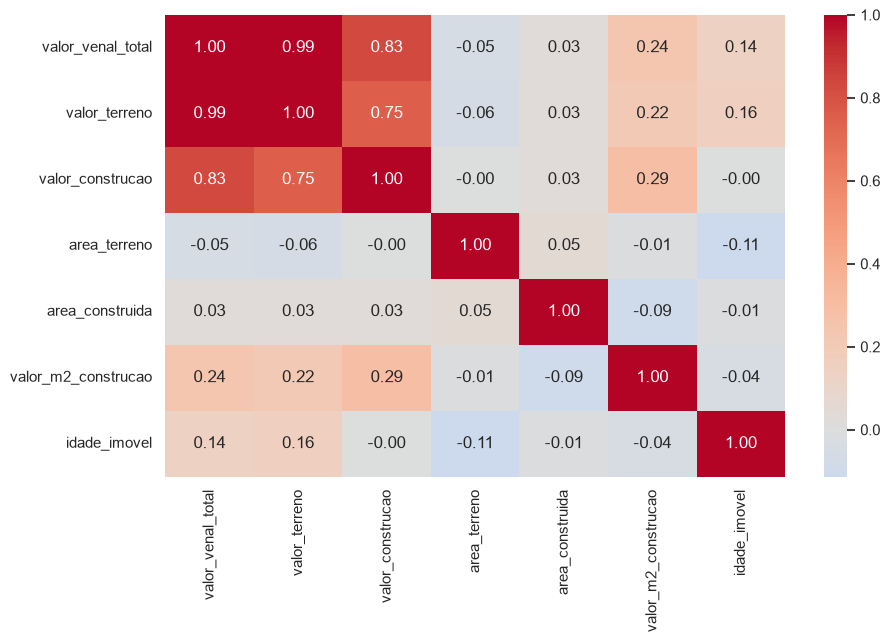

In [19]:
# análise de correlação entre variáveis numéricas
corr = df_iptu[
    [
        "valor_venal_total",
        "valor_terreno",
        "valor_construcao",
        "area_terreno",
        "area_construida",
        "valor_m2_construcao",
        "idade_imovel",
    ]
].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

In [16]:
df_iptu

,ano,data_cadastramento,numero_notificacao,numero_contribuinte,ano_inicio_vida_contribuinte,mes_inicio_vida_contribuinte,logradouro,numero_imovel,numero_condominio,complemento,...,area_ocupada,quantidade_pavimento,quantidade_esquina_imovel,testada_imovel,valor_terreno,valor_construcao,valor_venal_total,valor_m2_construcao,idade_imovel,regiao_cep
1,2025,2025-01-01,1,18311002567,2005,1,R EDMUNDO AMARAL VALENTE,81.0,05-1,CASA 11,...,3022,3,2,216.05,1177,1611,2788,5.442568,22.0,05
4,2025,2025-01-01,1,5619905861,2012,1,R ANTONIO DE LUCENA,22.0,02-7,AP 242,...,19585,28,4,555.00,3015,2644,5659,5.341414,14.0,03
5,2025,2025-01-01,1,5619905731,2012,1,R ANTONIO DE LUCENA,22.0,02-7,AP 181,...,19585,28,4,555.00,3015,2644,5659,5.341414,14.0,03
13,2025,2025-01-01,1,12310104913,2000,1,R NILZA MEDEIROS MARTINS,200.0,01-9,AP 152 E 3 VGS,...,35645,16,2,0.00,1454,2644,4098,6.221176,26.0,05
14,2025,2025-01-01,1,11409300292,1963,1,R BAIXADA SANTISTA,855.0,00-0,LT 22 QD 20,...,265,2,0,10.00,1799,1662,3461,3.743243,23.0,08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3806379,2025,2025-01-01,1,1003209173,2003,1,R BELA CINTRA,521.0,14-0,AP 1012 E VAGA,...,2000,29,0,15.00,9588,4360,13948,51.294118,23.0,01
3806412,2025,2025-01-01,1,901502596,2023,7,R ITAPEVA,569.0,02-7,SUITE 1440,...,14760,25,2,0.00,5723,4360,10083,12.281690,4.0,01
3806421,2025,2025-01-01,1,3605202535,2003,1,R SALTO,70.0,03-5,AP 804 E 1 VG,...,1495,17,0,38.50,7989,4360,12349,64.117647,24.0,04
3806424,2025,2025-01-01,1,901502499,2023,7,R ITAPEVA,569.0,02-7,SUITE 1248,...,14760,25,2,0.00,5723,4360,10083,25.952381,4.0,01


In [17]:
# salvando o dataframe processado
processed_path = os.path.join("..", "data", "processed", "iptu_2025_clean.csv")
os.makedirs(os.path.dirname(processed_path), exist_ok=True)
df_iptu.to_csv(processed_path, index=False)